In [1]:
# imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# make plots look decent
sns.set()
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
# load training data
train_file = '../data/train.jsonl'
train_data = []

with open(train_file, 'r', encoding='utf-8') as f:
    for line in f:
        train_data.append(json.loads(line))

print(f"Training samples: {len(train_data)}")

# load test data
test_file = '../data/test.jsonl'
test_data = []

with open(test_file, 'r', encoding='utf-8') as f:
    for line in f:
        test_data.append(json.loads(line))
        
print(f"test samples: {len(test_data)}")
print(f"Total: {len(train_data) + len(test_data)}")

Training samples: 288918
test samples: 72661
Total: 361579


In [9]:
# look at first article
first = train_data[0]
print("Keys:", first.keys())
print("Label:", first['label'])
print("\nText (first 200 chars):", first['text'][:200], "...")
# count each class
train_labels = [article['label'] for article in train_data]
test_labels = [article['label'] for article in test_data]

train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

print("Training set:")
for cls in sorted(train_counts.keys()):
    count = train_counts[cls]
    pct = (count / len(train_data)) * 100
    print(f"  Class {cls}: {count:6d} ({pct:5.1f}%)")

print("\ntest set:")
for cls in sorted(test_counts.keys()):
    count = test_counts[cls]
    pct = (count / len(test_data)) * 100
    print(f"  Class {cls}: {count:6d} ({pct:5.1f}%)")

Keys: dict_keys(['text', 'language', 'label', 'source_dataset', 'model', 'label_text'])
Label: 4

Text (first 200 chars): Have you ever had to wait for something for a really long time? Like waiting for your favorite food to cook or waiting for your turn on the swing at the park? It can be really hard to be patient, but  ...
Training set:
  Class 0:  75270 ( 26.1%)
  Class 1:  95398 ( 33.0%)
  Class 2:  91232 ( 31.6%)
  Class 3:  10740 (  3.7%)
  Class 4:  14910 (  5.2%)
  Class 5:   1368 (  0.5%)

test set:
  Class 0:  12330 ( 17.0%)
  Class 1:  12289 ( 16.9%)
  Class 2:  10137 ( 14.0%)
  Class 3:  37170 ( 51.2%)
  Class 4:    225 (  0.3%)
  Class 5:    510 (  0.7%)


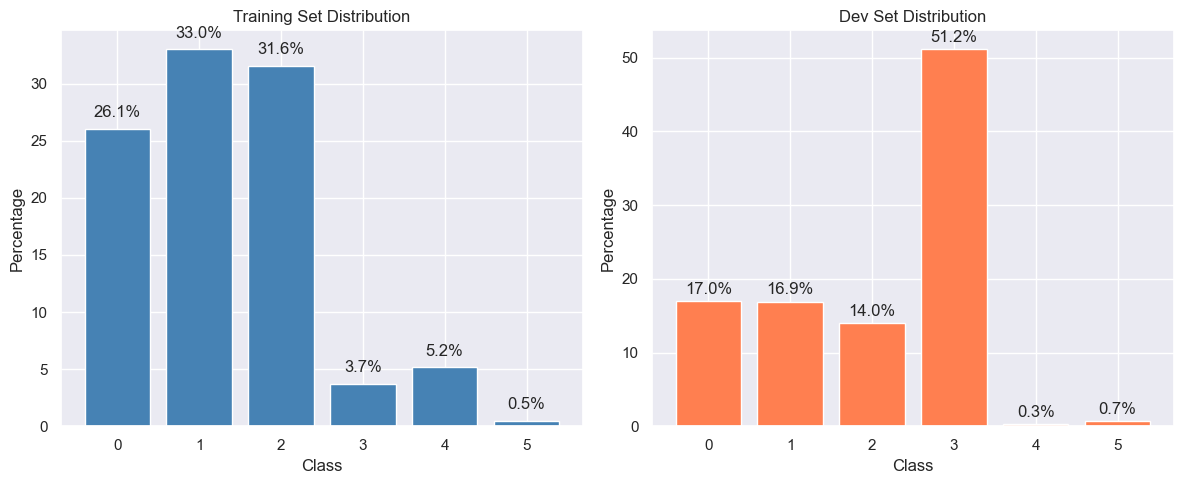

In [10]:
# plot train vs test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# training
classes = list(range(6))
train_pcts = [(train_counts[c] / len(train_data)) * 100 for c in classes]

ax1.bar(classes, train_pcts, color='steelblue')
ax1.set_xlabel('Class')
ax1.set_ylabel('Percentage')
ax1.set_title('Training Set Distribution')
ax1.set_xticks(classes)

# add percentages on bars
for i, v in enumerate(train_pcts):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center')

# dev
test_pcts = [(test_counts[c] / len(test_data)) * 100 for c in classes]

ax2.bar(classes, test_pcts, color='coral')
ax2.set_xlabel('Class')
ax2.set_ylabel('Percentage')
ax2.set_title('Dev Set Distribution')
ax2.set_xticks(classes)

for i, v in enumerate(test_pcts):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('../output/original_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

words:
  Min: 32 words
  Max: 3139 words
  Median: 215 words


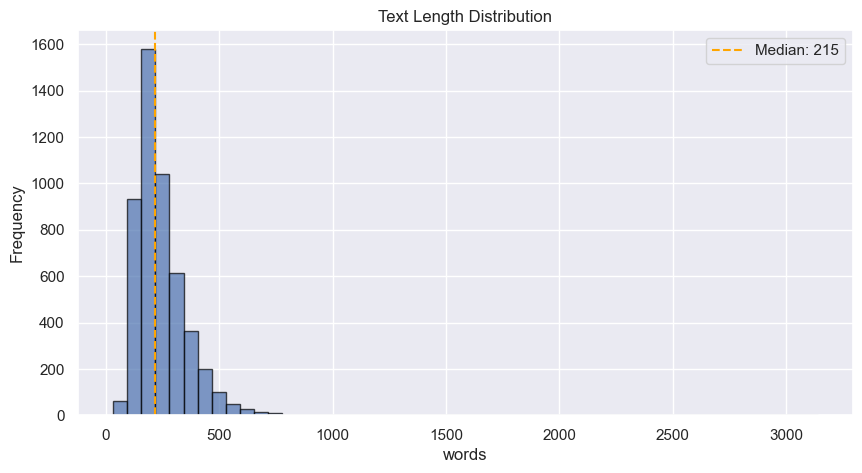

In [11]:
# check text lengths (sample for speed)
sample_size = 5000
sample_texts = [article['text'] for article in train_data[:sample_size]]
lengths = [len(text.split()) for text in sample_texts]

print(f"words:")
print(f"  Min: {min(lengths)} words")
print(f"  Max: {max(lengths)} words")
print(f"  Median: {np.median(lengths):.0f} words")

# plot
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('words')
plt.ylabel('Frequency')
plt.title('Text Length Distribution')
plt.axvline(np.median(lengths), color='orange', linestyle='--', label=f'Median: {np.median(lengths):.0f}')
plt.legend()
plt.savefig('../output/text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()